### Подключение библиотек и загрузка данных

In [43]:
import numpy as np
import pandas as pd
diabetes_df = pd.read_csv('diabetes_clean.csv')
diabetes_df.head(10)

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


### Исключение аномалий

In [44]:
diabetes_df = diabetes_df[diabetes_df['bmi'] > 0]
diabetes_df = diabetes_df[diabetes_df['glucose'] > 0]
diabetes_df = diabetes_df[diabetes_df['diastolic'] > 0]
diabetes_df = diabetes_df[diabetes_df['triceps'] > 0]
diabetes_df = diabetes_df[diabetes_df['insulin'] > 0]
diabetes_df = diabetes_df[diabetes_df['dpf'] > 0]
diabetes_df = diabetes_df[diabetes_df['age'] > 0]

### Разбивка данных на целевую переменную и массив признаков

In [45]:
X = diabetes_df.drop('glucose', axis=1).values
y = diabetes_df['glucose'].values

### Предсказание по одной переменной (BMI)

In [46]:
X_bmi = X[:, 4]
X_bmi = X_bmi.reshape(-1, 1)
print(y.shape, X_bmi.shape)

(392,) (392, 1)


### Просмотр данных (глюкоза/BMI)

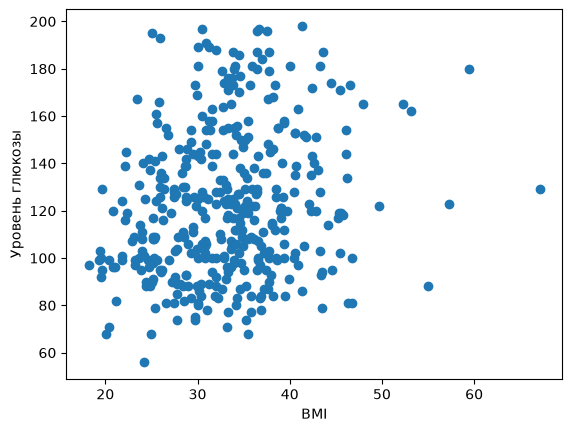

In [47]:
import matplotlib.pyplot as plt
plt.scatter(X_bmi, y)
plt.xlabel('BMI')
plt.ylabel('Уровень глюкозы')
plt.show()

#### Создание модели (BMI)

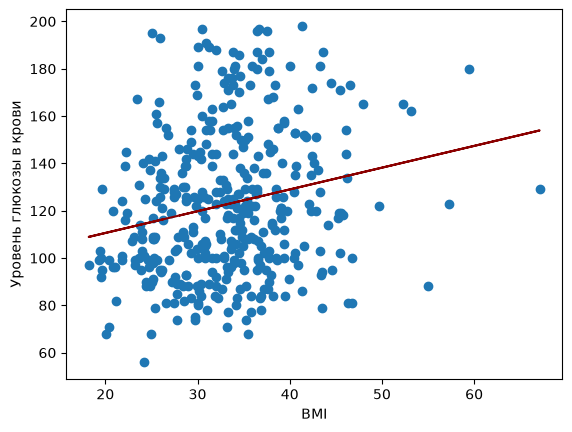

In [48]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_bmi, y)
predictions = reg.predict(X_bmi)
plt.scatter(X_bmi, y)
plt.plot(X_bmi, predictions, color='darkred')
plt.ylabel('Уровень глюкозы в крови')
plt.xlabel('BMI')
plt.show()

### Линейная модель для множества признаков

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_all = LinearRegression()
reg_all.fit(X_train, y_train).coef_

array([-4.58308886e-01,  1.25213192e-01,  1.67771319e-02,  1.08114705e-01,
       -3.38078216e-02, -1.24765440e+00,  3.53630747e-01,  2.27656959e+01])

In [50]:
y_pred = reg_all.predict(X_test)

In [51]:
reg_all.score(X_test, y_test)

0.5666969001355363

### Кросвалидация

In [61]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)
reg = LinearRegression()
cv_results = cross_val_score(reg, X, y, cv=kf)

In [62]:
cv_results

array([0.5827198 , 0.56318242, 0.38932834, 0.34221131, 0.15720348,
       0.43807582, 0.5523532 , 0.46155667, 0.42568832, 0.52136717])

In [63]:
print(np.mean(cv_results), np.std(cv_results))

0.4433686523540586 0.121429222864648


In [64]:
print(np.quantile(cv_results, [0.025, 0.975]))

[0.19883024 0.57832389]


### Гребневая регрессия

In [66]:
from sklearn.linear_model import Ridge
scores = []
for alpha in [0, 0.1, 1, 10, 100, 1000]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    scores.append(ridge.score(X_test, y_test))
print(scores)

[0.5666969001355364, 0.5668036049211143, 0.567706422127936, 0.5725915656308742, 0.5546920379064663, 0.518393405005131]


In [67]:
ridge = Ridge(alpha=10)

### Лассо регрессия

In [69]:
from sklearn.linear_model import Lasso
scores = []
for alpha in [0.01, 0.1, 1, 10, 20, 50]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    scores.append(lasso.score(X_test, y_test))
print(scores)

[0.5670213042003975, 0.5697454822740409, 0.5746032000511734, 0.49916712212094505, 0.483947623102858, 0.42836730456546923]


### Выбор признаков с помощью Лассо регресии

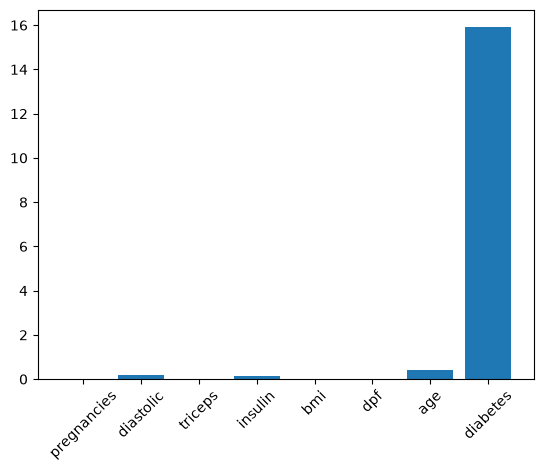

In [73]:
X = diabetes_df.drop('glucose', axis=1).values
y = diabetes_df['glucose']
names = diabetes_df.drop('glucose', axis=1).columns
lasso = Lasso(alpha=1)
lasso_coef = lasso.fit(X, y).coef_
plt.bar(names, lasso_coef)
plt.xticks(rotation=45)
plt.show()